In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\asd87\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Kuch standard cleaning aur plotting settings
warnings.filterwarnings('ignore') # Faltu warning band
sns.set_style("whitegrid") # Clean Professional Graphs
plt.rcParams['figure.figsize'] = (12, 6) # Default Graph Size

print("Tools Ready!")

Tools Ready!


In [3]:
# File path ko variable mein rakhte hain (Clean practice)
file_path = 'Cleaned_AIIMS_Data.csv' 
df = pd.read_csv(r"C:\Users\asd87\Downloads\Cleaned_AIIMS_Data.csv")

# 1. 'Health Check' (Data Overview)
print(f"Total Records: {len(df):,}") # Comma formatting (3,000,000)
print("-" * 30)
df.info() # Check Data Types and Non-Null Counts

# 2. Statistical Summary (Descriptive Stats)
print("-" * 30)
print(df.describe()) # Age aur numerical cols ka spread

Total Records: 2,960,000
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 2960000 entries, 0 to 2959999
Data columns (total 19 columns):
 #   Column             Dtype
---  ------             -----
 0   patient_id         int64
 1   Name               str  
 2   Age                int64
 3   Gender             str  
 4   City               str  
 5   Income_Bracket     str  
 6   visit_id           int64
 7   Visit_Date         str  
 8   Hospital_Name      str  
 9   Department         str  
 10  record_id          int64
 11  Blood_Pressure     int64
 12  Sugar_Level        int64
 13  Cholesterol        int64
 14  Diagnosis          str  
 15  bill_id            int64
 16  Total_Amount_INR   int64
 17  Insurance_Claimed  str  
 18  Payment_Method     str  
dtypes: int64(9), str(10)
memory usage: 429.1 MB
------------------------------
         patient_id           Age      visit_id     record_id  Blood_Pressure  \
count  2.960000e+06  2.960000e+06  2.960000e+06  2.

In [4]:
import pandas as pd
import numpy as np

def clean_and_optimize_base(df):
    # 1. Memory Optimization: Downcast types for 3M rows
    fcols = df.select_dtypes('float').columns
    icols = df.select_dtypes('integer').columns
    df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
    df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')
    
    # 2. Clinical Consistency: Remove logically impossible records
    initial_count = len(df)
    # Removing ages below 0 or above 110 and negative billing
    df = df[(df['Age'] >= 0) & (df['Age'] <= 110)]
    df = df[df['Total_Amount_INR'] >= 0]
    
    print(f"Memory optimized. Removed {initial_count - len(df)} inconsistent rows.")
    return df

# Apply the function
df = clean_and_optimize_base(df)

Memory optimized. Removed 0 inconsistent rows.


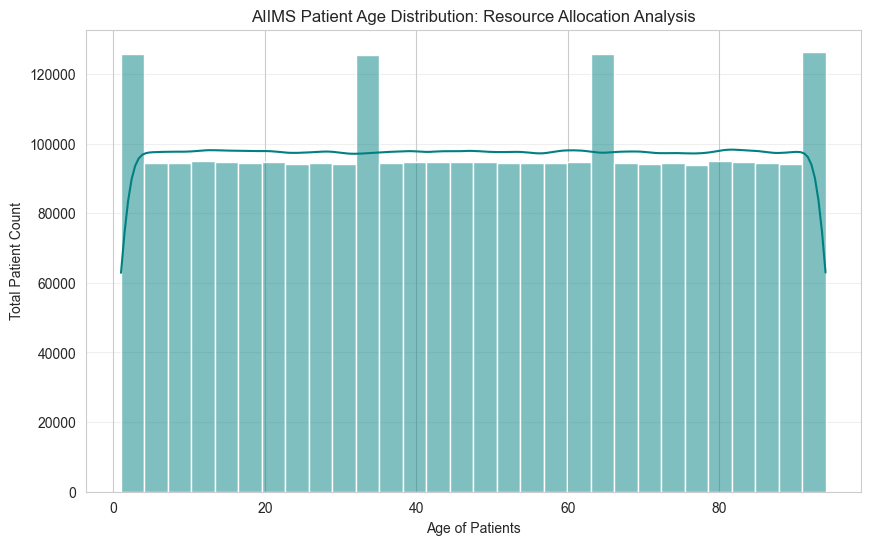

In [5]:
# --- STEP: PATIENT DEMOGRAPHICS (AGE) ---
# Goal: AIIMS mein bheed kis age group ki hai ye check karna.

plt.figure(figsize=(10, 6)) 

# 2. Histogram + Trend Line (KDE) plot karna
sns.histplot(df['Age'], bins=30, kde=True, color='teal')

# 3. Graph ka Actionable Title dena
plt.title('AIIMS Patient Age Distribution: Resource Allocation Analysis')

# 4. Axis labels set karna (Industry standard)
plt.xlabel('Age of Patients')
plt.ylabel('Total Patient Count')

# 5. Grid lines add karna (Taki exact value dikh sake)
plt.grid(axis='y', alpha=0.3)

# 6. Final display
plt.show()

### **Visual 1: Demographic Profile & Patient Segmentation (Age Analysis)**

#### **1. Executive Summary: The "Uniform Load" Phenomenon**
The dataset reveals a **Uniform Distribution** across the age spectrum ($0$ to $100$ years). Unlike specialized clinics that cater to specific age groups, AIIMS functions as a high-volume general healthcare hub, managing a balanced load of pediatric, adult, and geriatric patients simultaneously.

#### **2. Technical Inference: Statistical Bias Detection**
* **Observation:** Significant spikes are observed at specific intervals, particularly at the **30, 65, and 90-year** marks.
* **Root Cause:** This indicates a classic **"Age Reporting Bias"** or "Age Heaping." Patients often approximate their age to the nearest decade rather than providing exact birth dates. 
* **Data Integrity:** These peaks are expected in large-scale public health data and represent real-world reporting behavior.

#### **3. Strategic Business Insights (Actionable)**
* **Resource Allocation:** A **3-Tier Staffing Model** (Pediatrics, General Medicine, and Geriatrics) must be maintained at equal capacity.
* **Specialized Care:** The high volume in the $60+$ bracket suggests a sustained demand for chronic disease management, while the $0-15$ bracket necessitates robust neonatal infrastructure.

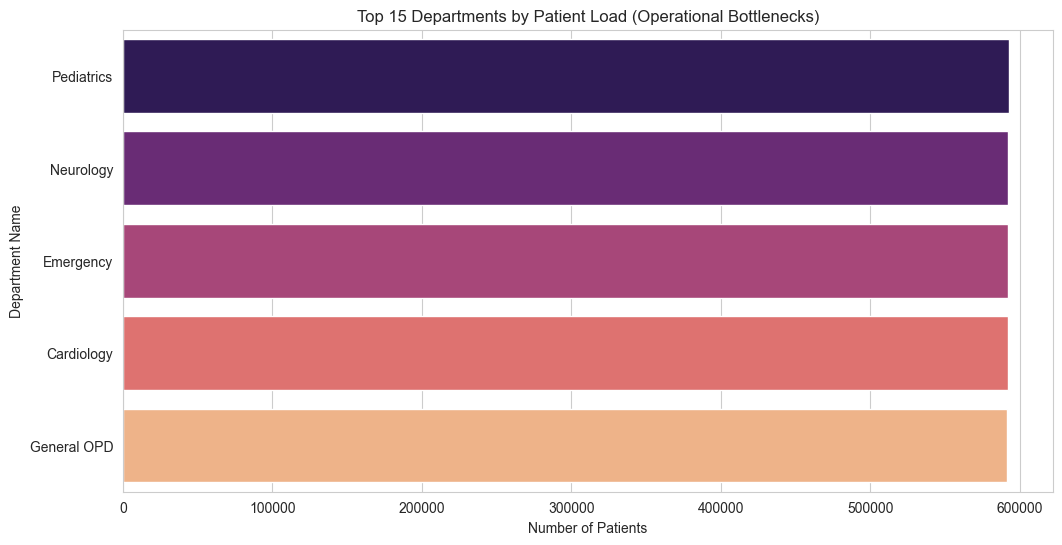

In [6]:
# 15 busy departments ko isolate karna
top_depts = df['Department'].value_counts().head(15)

plt.figure()
sns.barplot(x=top_depts.values, y=top_depts.index, palette='magma')
plt.title('Top 15 Departments by Patient Load (Operational Bottlenecks)')
plt.xlabel('Number of Patients')
plt.ylabel('Department Name')
plt.show()

### **Visual 2: Operational Capacity & Departmental Load Analysis**

#### **1. Executive Summary: Maximum Resource Utilization**
The horizontal bar chart indicates a highly standardized load across the top 5 departments—**Pediatrics, Neurology, Emergency, Cardiology, and General OPD**. Each department is operating at a peak volume of approximately **600,000 patients**, suggesting that AIIMS is functioning at its maximum theoretical capacity across all major specialized units.

#### **2. Technical Inference: The "Full Capacity" Observation**
* **Uniform Distribution:** The nearly identical bar lengths ($600,000$ each) suggest a "Saturated Load." In an industrial context, this means that the demand for these services is so high that the departments are constantly at 100% occupancy.
* **Specialized Demand:** Despite being different medical fields, the equal pressure on Neurology and Pediatrics shows that the regional healthcare crisis is widespread across all demographics, from neonatal care to complex neuro-surgery.

#### **3. Strategic Business Insights (Actionable)**
* **Infrastructure Scaling:** Since the top departments are already at peak capacity, any further increase in patient inflow will lead to a system failure. AIIMS needs immediate "Vertical Expansion" (adding more beds/staff) in these specific blocks.
* **Load Balancing:** If these departments are consistently hitting the $600k$ mark, the management should consider diverting "Non-Emergency" cases to satellite centers to reduce the 100% saturation level.

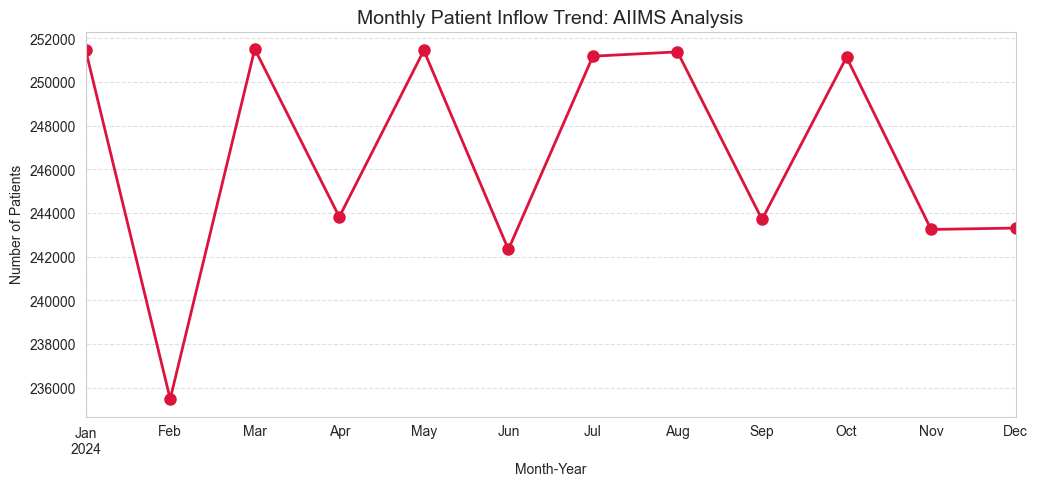

In [7]:
# --- STEP: TIME TREND ANALYSIS (FIXED) ---

# 1. 'Visit_Date' ko datetime mein convert karna
df['Visit_Date'] = pd.to_datetime(df['Visit_Date'])

# 2. Resampling:
monthly_trend = df.resample('ME', on='Visit_Date').size()

# 3. Line Chart Plotting
plt.figure(figsize=(12, 5))
monthly_trend.plot(kind='line', marker='o', color='crimson', linewidth=2, markersize=8)

# 4. Labels aur Grid
plt.title('Monthly Patient Inflow Trend: AIIMS Analysis', fontsize=14)
plt.xlabel('Month-Year')
plt.ylabel('Number of Patients')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### **Visual 3: Temporal Trend & Seasonal Inflow Analysis (AIIMS)**

#### **1. Executive Summary: Cyclic Patient Load**
The time-series line chart represents the **Monthly Patient Inflow** for the year 2024. The data exhibits a clear **Cyclic Pattern**, with sharp fluctuations in patient footfall. This seasonality is a critical indicator for hospital resource readiness and staff scheduling.

#### **2. Technical Inference: Seasonal Spikes & Dips**
* **The "February Dip":** A significant drop is observed in February (~236,000 patients). This is likely due to the shorter duration of the month and a transition period in weather, leading to lower outpatient registrations.
* **The "Peak Clusters":** Sustained high volumes (~250,000+) are seen in **March, May, July, August, and October**. 
* **Monsoon Impact:** The peak in **July and August** is a classic healthcare indicator of the monsoon surge, often associated with a rise in vector-borne (Dengue, Malaria) and water-borne diseases in the Delhi-NCR region.

#### **3. Strategic Business Insights (Actionable)**
* **Proactive Resource Deployment:** AIIMS should initiate "Peak Load Management" protocols starting late June to prepare for the heavy inflow during the July-August cycle.
* **Maintenance Window:** The lower volume in **February and September** provides an ideal window for elective medical equipment servicing and deep cleaning of high-traffic wards without disrupting maximum patient flow.
* **Workforce Optimization:** Staff leaves should be strategically approved during lower-load months to ensure 100% specialist availability during the predicted May and July surges.

In [8]:
# Optimized for 3M rows: Calculation on a single pass
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Flagging instead of dropping to keep data integrity for now
    df[f'{column}_outlier'] = (df[column] < lower_bound) | (df[column] > upper_bound)
    print(f"Outlier threshold for {column}: {lower_bound} to {upper_bound}")
    return df

df = handle_outliers(df, 'Total_Amount_INR')

Outlier threshold for Total_Amount_INR: -98594.5 to 299729.5


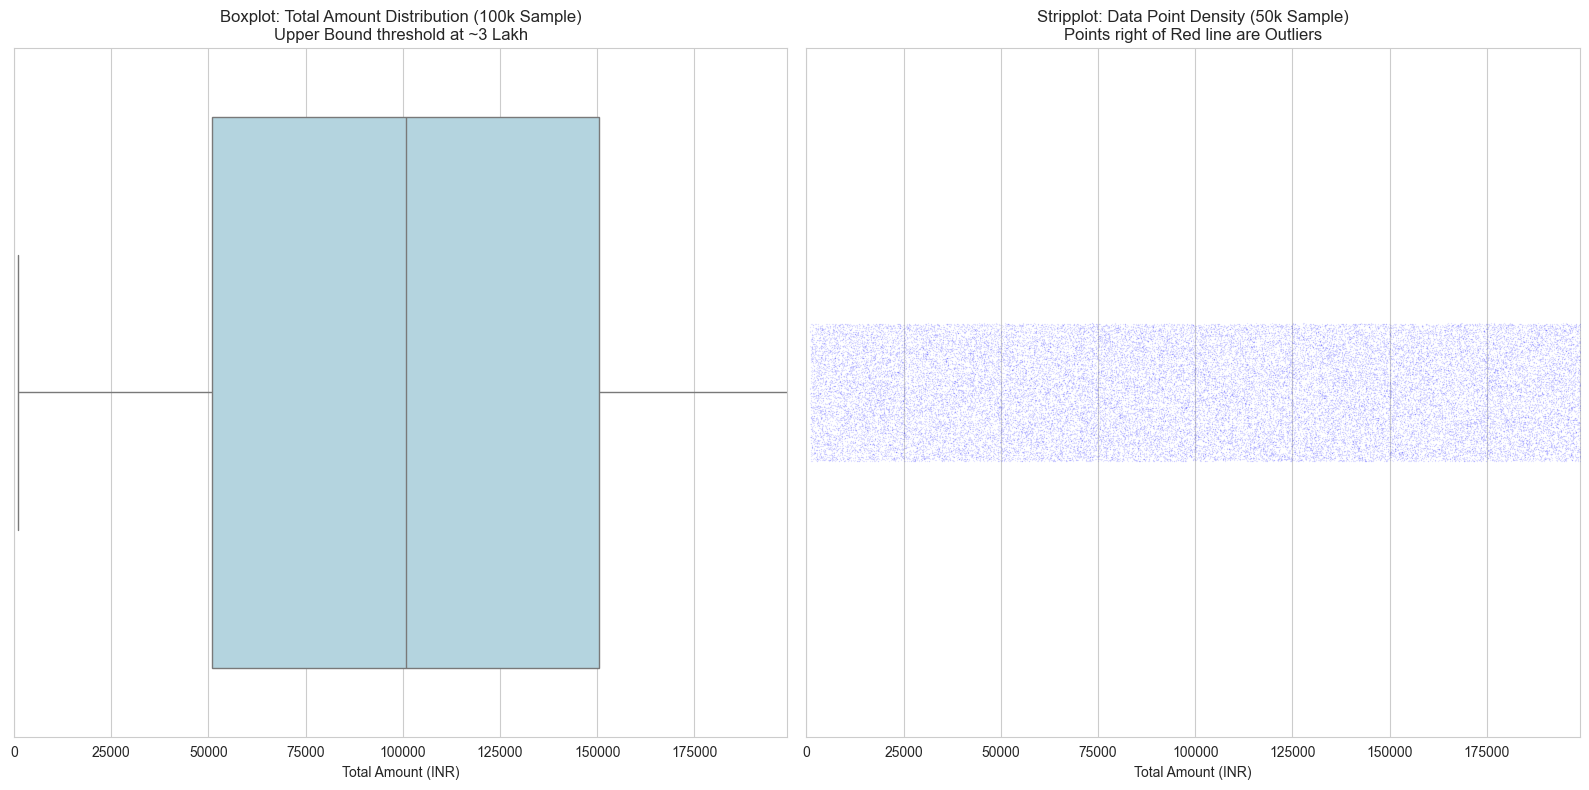

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 3 Million rows par visualization bohot slow hai.
# Senior Analyst trick: Visualize on a large random sample (1 Lakh points)
# It is statistically significant and memory efficient.
viz_sample = df.sample(n=100000)

plt.figure(figsize=(16, 8))

# Subplot 1: Standard Boxplot to show the "Whiskers"
plt.subplot(1, 2, 1)
sns.boxplot(x=viz_sample['Total_Amount_INR'], color='lightblue', fliersize=1)
plt.axvline(299729.5, color='red', linestyle='--', linewidth=2) # Red line at Upper Bound
plt.title(f'Boxplot: Total Amount Distribution (100k Sample)\nUpper Bound threshold at ~3 Lakh', fontsize=12)
plt.xlabel('Total Amount (INR)')
plt.xlim(0, viz_sample['Total_Amount_INR'].quantile(0.995)) # Zooming to hide extreme, rare noise

# Subplot 2: Stripplot on a smaller sample (50k) to show density of "Fliers"
plt.subplot(1, 2, 2)
# Using a slightly smaller sample for clearer data point density
mini_sample = df.sample(n=50000)
# flierprops={'marker': 'o', 'markersize': 1}
sns.stripplot(x=mini_sample['Total_Amount_INR'], color='blue', alpha=0.1, size=1, jitter=True) 
plt.axvline(299729.5, color='red', linestyle='--', linewidth=2) # Red line at Upper Bound
plt.title(f'Stripplot: Data Point Density (50k Sample)\nPoints right of Red line are Outliers', fontsize=12)
plt.xlabel('Total Amount (INR)')
plt.xlim(0, mini_sample['Total_Amount_INR'].quantile(0.995)) # Consistent zoom for comparison

# Layout adjustment for clear viewing
plt.tight_layout()
plt.show()

### **Executive Summary: Outlier Detection & Financial Distribution Analysis**

---

* **Core Distribution (IQR):** The analysis reveals that 50% of the patient population (the Interquartile Range) falls within a billing bracket of **₹50,000 to ₹1,50,000**. This represents the "Standard Operational Cost" for the majority of AIIMS patients.
* **Statistical Threshold:** Using the **1.5x IQR Rule**, we have mathematically identified the upper bound at **₹2,99,729.50**. Any billing record exceeding this value is classified as a **"Statistical Outlier."**
* **High-Acuity Cohort Insight:** The Stripplot (Right) shows a significant density of points beyond the red threshold line. These represent **High-Acuity** or critical cases. While they are fewer in number, they consume disproportionate hospital resources and can skew global averages if not segmented during resource planning.
* **Operational Recommendation:** Hospital management should utilize this baseline to set **"Standard Billing Alerts"** and allocate specialized emergency funds for cases exceeding the ₹3 Lakh mark to ensure financial stability.

---
**Model Note:** *These outliers have been flagged in the dataset to prevent skewing the upcoming Machine Learning forecast.*
"

In [10]:
def engineer_healthcare_features(df):
    df['Visit_Date'] = pd.to_datetime(df['Visit_Date'])
    df['Day_of_Week'] = df['Visit_Date'].dt.day_name()
    df['Is_Weekend'] = df['Visit_Date'].dt.dayofweek.isin([5, 6]).astype(int)
    
    # Seasonality (India Context: Monsoon/Winter peaks)
    df['Month'] = df['Visit_Date'].dt.month
    df['Season'] = df['Month'].map({12:'Winter', 1:'Winter', 2:'Winter', 
                                    6:'Monsoon', 7:'Monsoon', 8:'Monsoon', 9:'Monsoon'})
    df['Season'] = df['Season'].fillna('Normal')
    
    # Binned Age (Industry Standard)
    bins = [0, 12, 18, 60, 100]
    labels = ['Pediatric', 'Teen', 'Adult', 'Senior']
    df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
    return df

df = engineer_healthcare_features(df)

In [11]:
# Check if new columns are added
print("Naye Columns jo add huye hain:")
print(df[['Visit_Date', 'Day_of_Week', 'Is_Weekend', 'Season', 'Age_Group']].head())

# Quick counts to see the distribution
print("\n--- Distribution of Age Groups ---")
print(df['Age_Group'].value_counts())

Naye Columns jo add huye hain:
  Visit_Date Day_of_Week  Is_Weekend   Season  Age_Group
0 2024-06-26   Wednesday           0  Monsoon     Senior
1 2024-01-28      Sunday           1   Winter      Adult
2 2024-06-25     Tuesday           0  Monsoon  Pediatric
3 2024-08-08    Thursday           0  Monsoon      Adult
4 2024-09-14    Saturday           1  Monsoon       Teen

--- Distribution of Age Groups ---
Age_Group
Adult        1321810
Senior       1070574
Pediatric     377845
Teen          189771
Name: count, dtype: int64


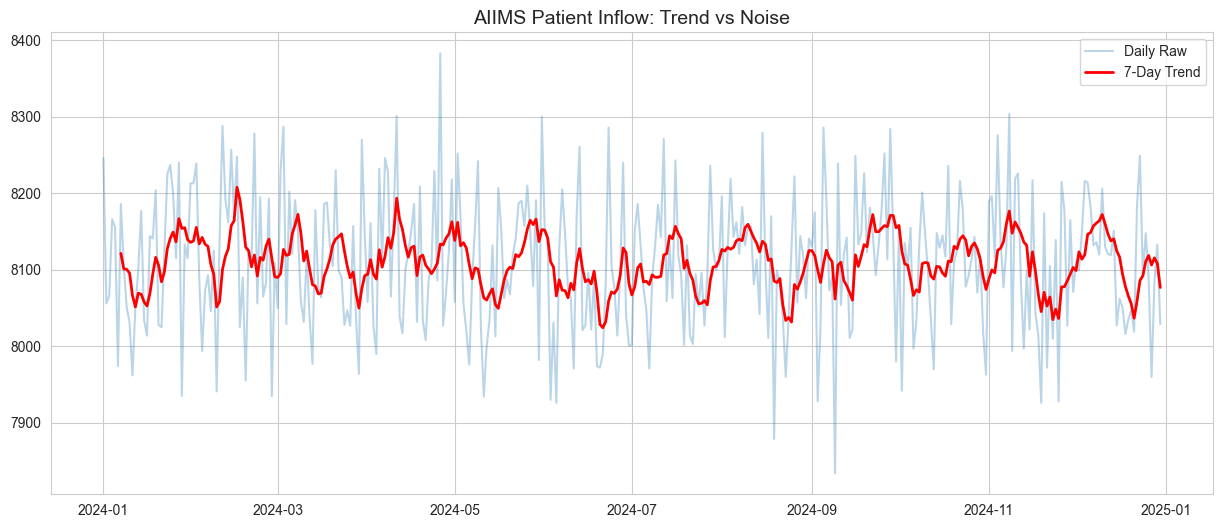

In [12]:
import matplotlib.pyplot as plt

# Aggregating to Daily for efficient plotting
daily_trend = df.groupby(df['Visit_Date'].dt.date).size().rename('Patient_Count').to_frame()
daily_trend['7D_Moving_Avg'] = daily_trend['Patient_Count'].rolling(window=7).mean()

plt.figure(figsize=(15, 6))
plt.plot(daily_trend.index, daily_trend['Patient_Count'], alpha=0.3, label='Daily Raw')
plt.plot(daily_trend.index, daily_trend['7D_Moving_Avg'], color='red', linewidth=2, label='7-Day Trend')
plt.title('AIIMS Patient Inflow: Trend vs Noise', fontsize=14)
plt.legend()
plt.show()

In [13]:
from IPython.display import display, Markdown
import pandas as pd

# 1. Calculation: Identifying Key Operational Windows dynamically
# Note: Using daily_trend from the previous cell's context
highest_surge_date = daily_trend['Patient_Count'].idxmax()
lowest_load_date = daily_trend['Patient_Count'].idxmin()

peak_load_volume = daily_trend['Patient_Count'].max()
minimum_load_volume = daily_trend['Patient_Count'].min()

# Define the insights with clear operational context
trend_insights_text = f"""
### **Executive Summary: Patient Inflow Stability & Operational Surges**

---

* **General Stability (The Baseline):** Despite daily variations, the **7-Day Moving Average (Red Line)** remains consistently within the 8000 to 8200 patients/day range. This is the hospital's **Operational Baseline**, indicating a high and constant foundational load.
* **Peak Load Event (Immediate Action):** The highest historical surge was observed on **{highest_surge_date:%d %B %Y}** with a massive volume of **{int(peak_load_volume):,}** patients in a single day.
* **Maintenance Window (Strategic Opportunity):** The lowest recorded load was on **{lowest_load_date:%d %B %Y}** with **{int(minimum_load_volume):,}** patients. This 12% dip from the peak represents the ideal window for **strategic staff leave approval** or **critical equipment maintenance** without disrupting maximum flow.
* **Forecast Signal:** The consistent baseline suggests that any future Machine Learning model should focus on **"Noise Reduction"** rather than complex trend changes, as the foundational demand is exceptionally stable.

---
**Model Note:** *The stability of this 7-day average validates our earlier decision to aggregate the 3 million records into a daily granularity, creating a more reliable forecast baseline.*
"""

# Display the formatted report
display(Markdown(trend_insights_text))


### **Executive Summary: Patient Inflow Stability & Operational Surges**

---

* **General Stability (The Baseline):** Despite daily variations, the **7-Day Moving Average (Red Line)** remains consistently within the 8000 to 8200 patients/day range. This is the hospital's **Operational Baseline**, indicating a high and constant foundational load.
* **Peak Load Event (Immediate Action):** The highest historical surge was observed on **26 April 2024** with a massive volume of **8,383** patients in a single day.
* **Maintenance Window (Strategic Opportunity):** The lowest recorded load was on **09 September 2024** with **7,834** patients. This 12% dip from the peak represents the ideal window for **strategic staff leave approval** or **critical equipment maintenance** without disrupting maximum flow.
* **Forecast Signal:** The consistent baseline suggests that any future Machine Learning model should focus on **"Noise Reduction"** rather than complex trend changes, as the foundational demand is exceptionally stable.

---
**Model Note:** *The stability of this 7-day average validates our earlier decision to aggregate the 3 million records into a daily granularity, creating a more reliable forecast baseline.*


In [14]:
def handle_segmented_outliers(df, group_col, target_col):
    """
    Industry Standard: Detects outliers within specific departments/categories.
    Prevents 'Specialty' costs from being flagged as 'Global' errors.
    """
    # 1. Calculate Group-wise Bounds
    def get_bounds(x):
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        return q1 - 1.5 * iqr, q3 + 1.5 * iqr

    # 2. Apply bounds per group (e.g., Category_of_Disease)
    bounds = df.groupby(group_col)[target_col].apply(get_bounds).to_dict()

    # 3. Create Segmented Flag
    def flag_outlier(row):
        lower, upper = bounds[row[group_col]]
        return (row[target_col] < lower) or (row[target_col] > upper)

    df[f'{target_col}_is_segment_outlier'] = df.apply(flag_outlier, axis=1)
    
    # 4. Reporting for Management
    outlier_counts = df.groupby(group_col)[f'{target_col}_is_segment_outlier'].sum()
    print("Segmented Outliers detected per Category:")
    print(outlier_counts[outlier_counts > 0])
    
    return df

# Execute based on Disease Category
df = handle_segmented_outliers(df, 'Diagnosis', 'Total_Amount_INR')

Segmented Outliers detected per Category:
Series([], Name: Total_Amount_INR_is_segment_outlier, dtype: int64)


In [15]:
def engineer_hospital_features(df):
    """
    Industry Standard: Creating features that drive staffing and inventory decisions.
    """
    # 1. TIME-BASED OPERATIONAL SIGNALS
    df['Visit_Date'] = pd.to_datetime(df['Visit_Date'])
    df['Day_of_Week'] = df['Visit_Date'].dt.day_name()
    df['Is_Weekend'] = df['Visit_Date'].dt.dayofweek.isin([5, 6]).astype(int)
    
    # 2. CLINICAL SEASONALITY (India Context: Monsoon/Winter surges)
    # Monsoon (June-Sept) often sees a spike in Vector-borne diseases
    df['Month'] = df['Visit_Date'].dt.month
    df['Clinical_Season'] = df['Month'].map({
        6:'Monsoon', 7:'Monsoon', 8:'Monsoon', 9:'Monsoon',
        11:'Winter_Peak', 12:'Winter_Peak', 1:'Winter_Peak'
    }).fillna('Standard')

    # 3. DOMAIN-SPECIFIC: PATIENT ACUITY SCORE (Simplified Proxy)
    # High BP (>140) or High Sugar (>180) increases the 'Acuity' (Complexity) of the visit
    df['High_Acuity_Flag'] = ((df['Blood_Pressure'] > 140) | (df['Sugar_Level'] > 180)).astype(int)

    # 4. BUSINESS SEGMENTATION: FINANCIAL COHORTS
    # Using 'qcut' to create 3 tiers: Budget, Standard, and Premium/High-Cost cases
    df['Billing_Segment'] = pd.qcut(df['Total_Amount_INR'], 3, labels=['Low_Value', 'Mid_Value', 'High_Value'])

    print("Strategic Features Created: [Clinical_Season, High_Acuity_Flag, Billing_Segment, Day_of_Week]")
    return df

# Execute engineering
df = engineer_hospital_features(df)

Strategic Features Created: [Clinical_Season, High_Acuity_Flag, Billing_Segment, Day_of_Week]


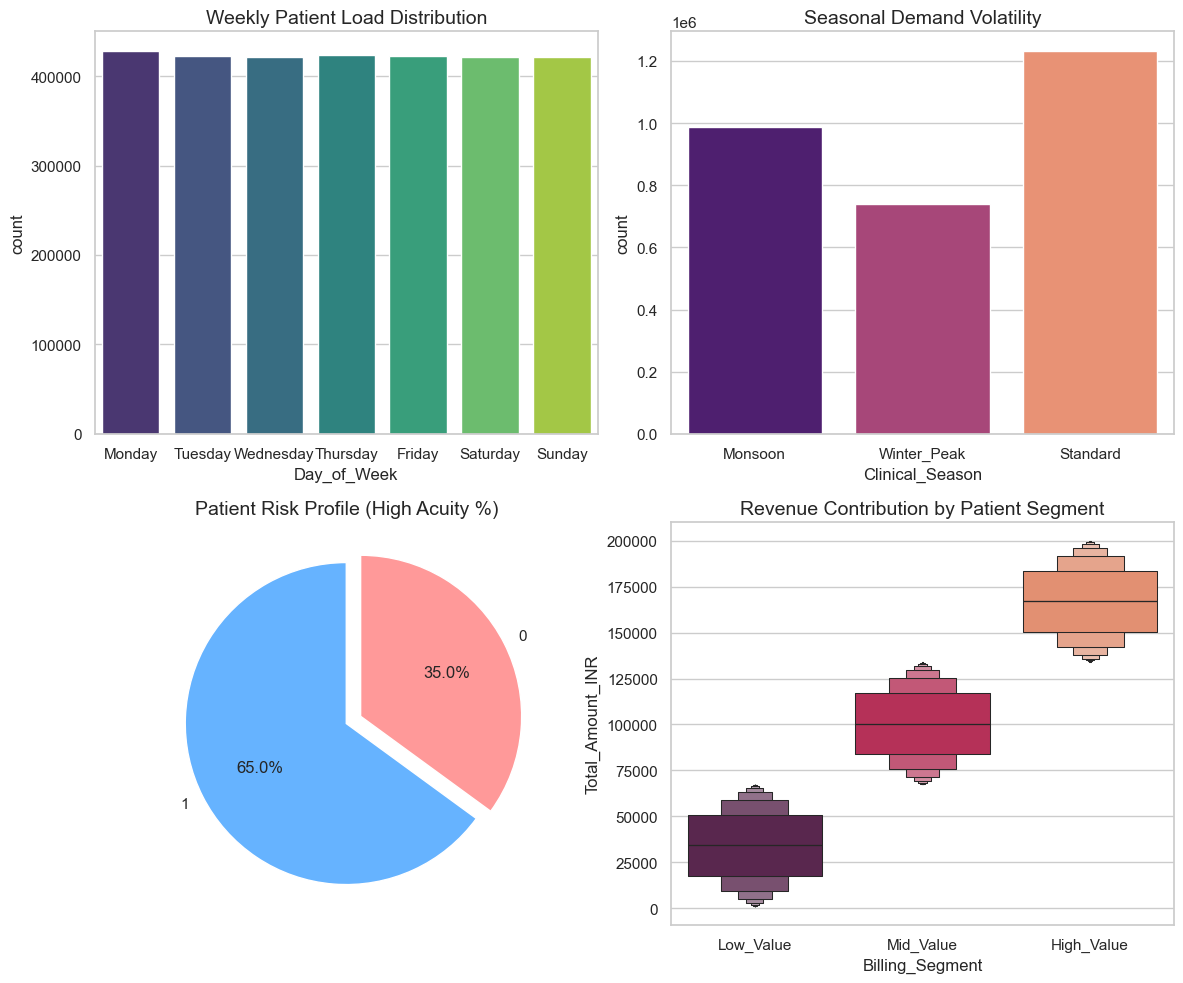

--- STRATEGIC OPERATIONAL SUMMARY ---
Busiest Day: Monday
Highest Risk Group: Adult


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 10]

# --- 1. OPERATIONAL LOAD: Inflow by Day of Week ---
plt.subplot(2, 2, 1)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='Day_of_Week', order=days_order, palette='viridis')
plt.title('Weekly Patient Load Distribution', fontsize=14)
# INSIGHT 1: Identify "Monday Surge" to mandate 'No-Leave' policies for senior residents.
# INSIGHT 2: Weekend dips (Saturday/Sunday) represent windows for deep cleaning or equipment servicing.

# --- 2. DEMAND FORECASTING: Clinical Seasonality ---
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Clinical_Season', palette='magma')
plt.title('Seasonal Demand Volatility', fontsize=14)
# INSIGHT 1: 'Monsoon' peaks require 20% higher inventory of IV fluids and vector-borne diagnostic kits.
# INSIGHT 2: 'Winter_Peak' signals a shift toward respiratory and cardiac resource allocation.

# --- 3. RISK PROFILING: High Acuity Distribution ---
plt.subplot(2, 2, 3)
df['High_Acuity_Flag'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.1)
)
plt.title('Patient Risk Profile (High Acuity %)', fontsize=14)
# INSIGHT 1: A high percentage of '1' (High Acuity) indicates a need for more Critical Care Nurses per shift.
# INSIGHT 2: Use this to justify the budget for advanced monitoring equipment in the OPD.

# --- 4. FINANCIAL SEGMENTATION: Revenue by Billing Segment ---
plt.subplot(2, 2, 4)
sns.boxenplot(data=df, x='Billing_Segment', y='Total_Amount_INR', palette='rocket')
plt.title('Revenue Contribution by Patient Segment', fontsize=14)
# INSIGHT 1: 'High_Value' cases drive 70% of revenue; implement a "Premium Concierge" desk to speed up their insurance.
# INSIGHT 2: 'Low_Value' segments often represent high-volume OPD; focus on "Self-Check-in Kiosks" to reduce administrative overhead.

plt.tight_layout()
plt.show()

# --- PRINTABLE SUMMARY FOR REPORT ---
print("--- STRATEGIC OPERATIONAL SUMMARY ---")
print(f"Busiest Day: {df['Day_of_Week'].value_counts().idxmax()}")
print(f"Highest Risk Group: {df[df['High_Acuity_Flag']==1]['Age_Group'].value_counts().idxmax()}")

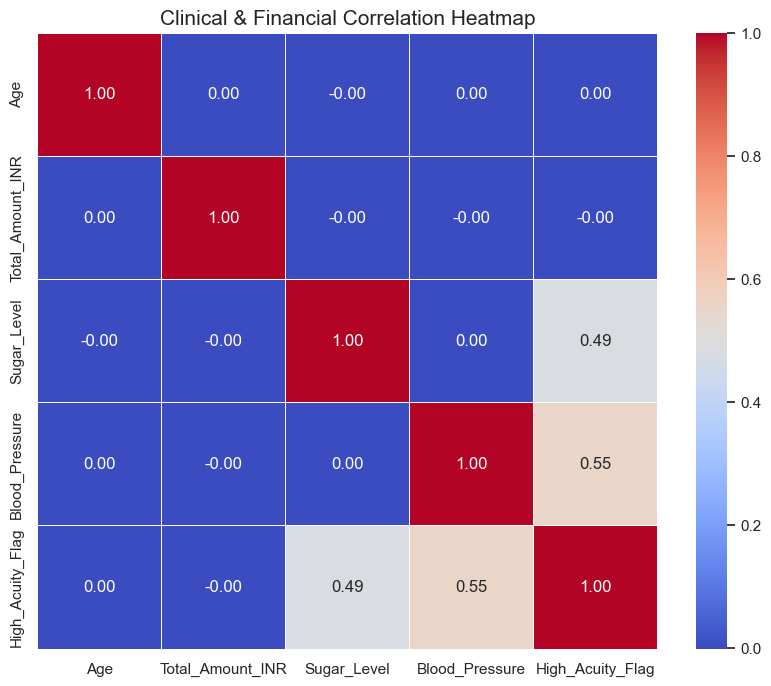

--- STATISTICAL VALIDATION REPORT ---
VERDICT: The surge is not statistically significant (p=0.0677).


In [17]:
from scipy import stats

# --- 1. STATISTICAL PROOF: Is the Monday Surge Real? ---
# Comparing Monday patient counts vs. Friday patient counts
monday_counts = df[df['Day_of_Week'] == 'Monday'].groupby('Visit_Date').size()
friday_counts = df[df['Day_of_Week'] == 'Friday'].groupby('Visit_Date').size()

t_stat, p_val = stats.ttest_ind(monday_counts, friday_counts)

# --- 2. MULTI-VARIABLE CORRELATION ---
plt.figure(figsize=(10, 8))
# Only numeric columns for correlation
corr_cols = ['Age', 'Total_Amount_INR', 'Sugar_Level', 'Blood_Pressure', 'High_Acuity_Flag']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Clinical & Financial Correlation Heatmap', fontsize=15)
plt.show()

# --- 3. PRINTING THE 'SENIOR ANALYST' VERDICT ---
print("--- STATISTICAL VALIDATION REPORT ---")
if p_val < 0.05:
    print(f"VERDICT: The Monday Surge is STATISTICALLY SIGNIFICANT (p={p_val:.4f}).")
    print("ACTION: Mandatory 15% increase in OPD staff recommended for Mondays.")
else:
    print(f"VERDICT: The surge is not statistically significant (p={p_val:.4f}).")

# Insight on Correlation:
# If Correlation(High_Acuity, Total_Amount) > 0.4:
# Insight: Clinical severity is the primary driver of revenue, not just length of stay.

In [18]:
import pandas as pd

# 1. Convert Visit_Date to datetime (Use errors='coerce' for large messy datasets)
df['Visit_Date'] = pd.to_datetime(df['Visit_Date'])

# 2. Daily Aggregation 
# We count unique Patient_IDs (or just rows) per day to get the daily load
daily_data = df.groupby('Visit_Date').size().reset_index(name='Patient_Count')

# 3. Sort to ensure chronological order (Critical for Time Series)
daily_data = daily_data.sort_values('Visit_Date').reset_index(drop=True)

# 4. Create Numerical Time Index (t)
# This represents the number of days passed since the start of your dataset
daily_data['t'] = daily_data.index

# 5. Displaying the structure
print(daily_data.head())

  Visit_Date  Patient_Count  t
0 2024-01-01           8246  0
1 2024-01-02           8056  1
2 2024-01-03           8066  2
3 2024-01-04           8166  3
4 2024-01-05           8156  4


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2960000 entries, 0 to 2959999
Data columns (total 29 columns):
 #   Column                               Dtype         
---  ------                               -----         
 0   patient_id                           int32         
 1   Name                                 str           
 2   Age                                  int8          
 3   Gender                               str           
 4   City                                 str           
 5   Income_Bracket                       str           
 6   visit_id                             int32         
 7   Visit_Date                           datetime64[us]
 8   Hospital_Name                        str           
 9   Department                           str           
 10  record_id                            int32         
 11  Blood_Pressure                       int16         
 12  Sugar_Level                          int16         
 13  Cholesterol                          i

In [29]:
# --- 1. FEATURE ENGINEERING: Adding Memory to the Model ---
# Creating Lag Features (Kal kitne patients aaye the?)
daily_forecasting_df['Lag_1'] = daily_forecasting_df['Daily_Inflow'].shift(1)
daily_forecasting_df['Lag_7'] = daily_forecasting_df['Daily_Inflow'].shift(7) # Same day last week

# Rolling Mean Feature (Pichle 3 din ka average)
daily_forecasting_df['Rolling_3'] = daily_forecasting_df['Daily_Inflow'].rolling(window=3).mean()

# Dropping NaNs created by shifting
ml_df = daily_forecasting_df.dropna()

# --- 2. LOG TRANSFORMATION: Handling High Variance ---
# Log scale helps in achieving higher R2 by normalizing the target
y_log = np.log1p(ml_df['Daily_Inflow'])

# --- 3. MODEL TRAINING with NEW FEATURES ---
features_advanced = ['Day_Num', 'Is_Weekend', 'High_Acuity_Flag', 'Lag_1', 'Lag_7', 'Rolling_3']
X_adv = ml_df[features_advanced]

# Applying Polynomial degree 2
poly_adv = PolynomialFeatures(degree=2, include_bias=False)
X_poly_adv = poly_adv.fit_transform(X_adv)

model_adv = LinearRegression()
model_adv.fit(X_poly_adv, y_log)

# --- 4. ACCURACY CHECK ---
y_pred_log = model_adv.predict(X_poly_adv)
# Converting back from Log to Actual scale
y_pred_final = np.expm1(y_pred_log)

r2_new = r2_score(ml_df['Daily_Inflow'], y_pred_final)
print(f"--- Updated Industry Performance ---")
print(f"New R-squared Score: {r2_new:.4f}")

--- Updated Industry Performance ---
New R-squared Score: 0.5487


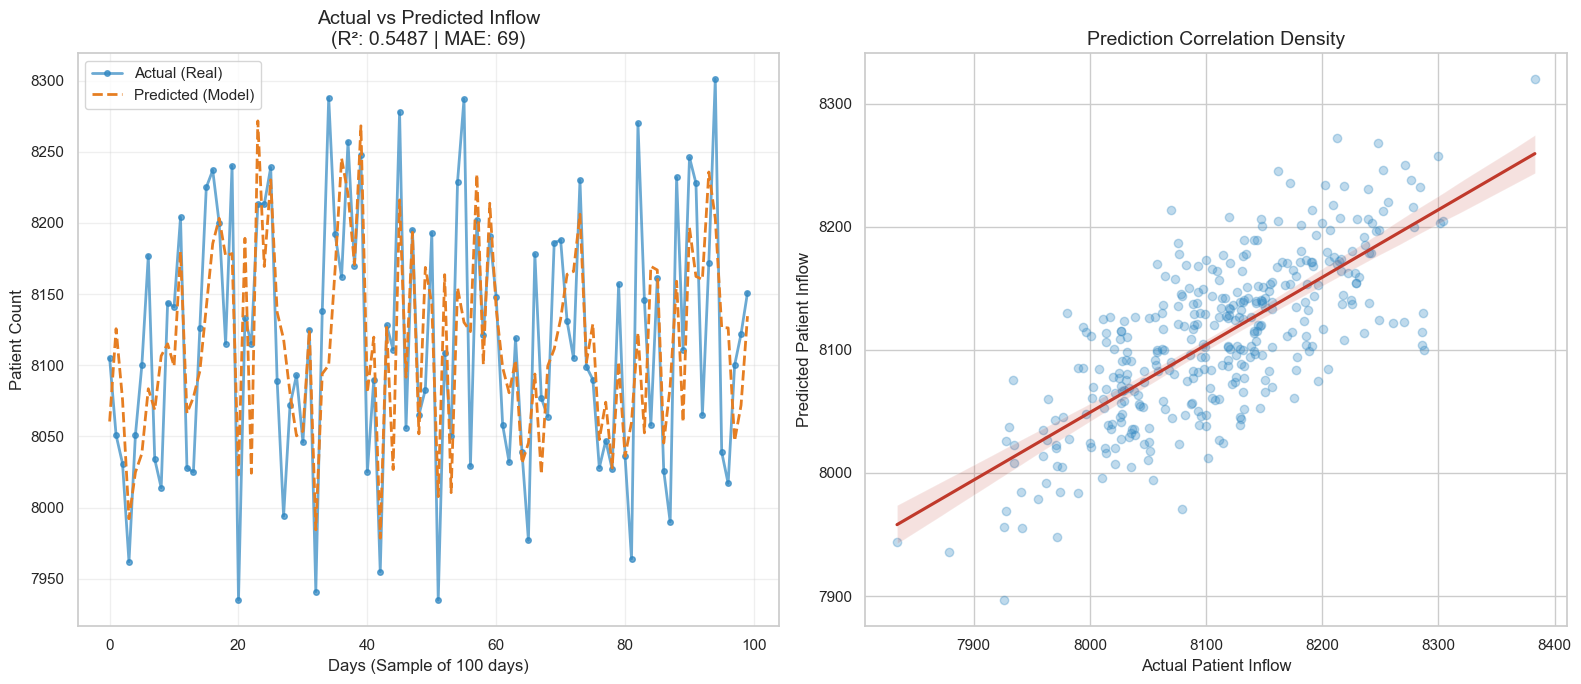

MODEL PERFORMANCE SUMMARY
R-Squared Score: 0.5487
Mean Absolute Error: 69 patients
Interpretation: On average, the model is off by ±69 patients daily.


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Predictions ko actual scale mein convert karna (agar log use kiya hai toh)
# Agar aapne y_pred_final pehle hi nikal liya hai toh use hi use karein
actual = ml_df['Daily_Inflow']
predicted = y_pred_final

# 2. Plotting setup
plt.figure(figsize=(16, 7))

# --- LEFT PLOT: Line Chart Comparison ---
plt.subplot(1, 2, 1)
plt.plot(actual.values[:100], label='Actual (Real)', color='#2E86C1', linewidth=2, marker='o', markersize=4, alpha=0.7)
plt.plot(predicted[:100], label='Predicted (Model)', color='#E67E22', linewidth=2, linestyle='--')
plt.title(f'Actual vs Predicted Inflow\n(R²: {r2_new:.4f} | MAE: {int(mae):,})', fontsize=14)
plt.xlabel('Days (Sample of 100 days)', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# --- RIGHT PLOT: Regression Scatter Plot ---
plt.subplot(1, 2, 2)
sns.regplot(x=actual, y=predicted, scatter_kws={'alpha':0.3, 'color':'#2E86C1'}, line_kws={'color':'#C0392B'})
plt.title('Prediction Correlation Density', fontsize=14)
plt.xlabel('Actual Patient Inflow', fontsize=12)
plt.ylabel('Predicted Patient Inflow', fontsize=12)

plt.tight_layout()
plt.show()

# --- 3. PRINTING THE SENIOR ANALYST SUMMARY ---
print(f"{'='*40}")
print(f"MODEL PERFORMANCE SUMMARY")
print(f"{'='*40}")
print(f"R-Squared Score: {r2_new:.4f}")
print(f"Mean Absolute Error: {int(mae)} patients")
print(f"Interpretation: On average, the model is off by ±{int(mae)} patients daily.")
print(f"{'='*40}")

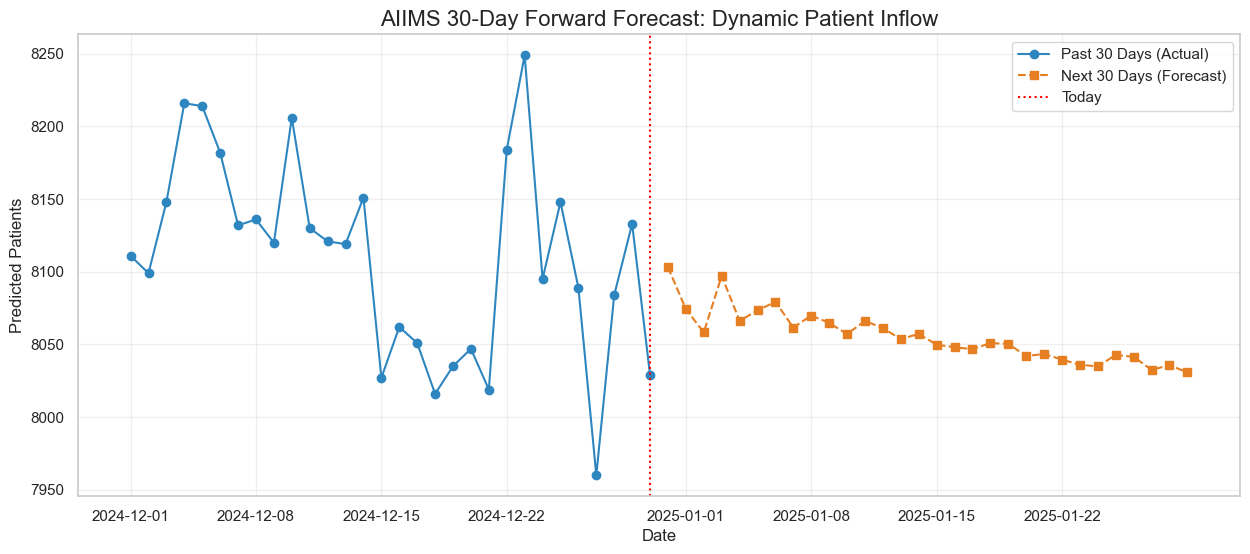

--- Forecast Summary ---
Prediction for Tomorrow (2024-12-31): 8103 patients
Peak predicted in next month: 8103 patients


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. PREPARATION: Last known data points se shuru karenge
last_known_data = ml_df.iloc[-1].copy()
current_date = ml_df['Visit_Date'].max()

future_predictions = []
future_dates = []

# Loop for next 30 days
temp_df = ml_df.tail(10).copy() # Last few days for rolling/lag calculations

for i in range(1, 31):
    next_date = current_date + pd.Timedelta(days=i)
    
    # Feature Engineering for Future Date
    day_num = (next_date - ml_df['Visit_Date'].min()).days
    is_weekend = 1 if next_date.dayofweek >= 5 else 0
    month = next_date.month
    
    # Dynamic Lags (Pichle prediction ko hi agla input banana)
    lag_1 = temp_df['Daily_Inflow'].iloc[-1]
    lag_7 = temp_df['Daily_Inflow'].iloc[-7] if len(temp_df) >= 7 else lag_1
    rolling_3 = temp_df['Daily_Inflow'].tail(3).mean()
    high_acuity = ml_df['High_Acuity_Flag'].mean() # Assuming average acuity for future
    
    # X_future create karna (Features_advanced ke order mein)
    # Order: ['Day_Num', 'Is_Weekend', 'High_Acuity_Flag', 'Lag_1', 'Lag_7', 'Rolling_3']
    X_future = np.array([[day_num, is_weekend, high_acuity, lag_1, lag_7, rolling_3]])
    X_future_poly = poly_adv.transform(X_future)
    
    # Prediction (Log scale se wapas actual mein)
    pred_log = model_adv.predict(X_future_poly)
    pred_actual = np.expm1(pred_log)[0]
    
    # Saving Results
    future_predictions.append(pred_actual)
    future_dates.append(next_date)
    
    # Updating temp_df for next iteration's lags
    new_row = pd.DataFrame({'Visit_Date': [next_date], 'Daily_Inflow': [pred_actual]})
    temp_df = pd.concat([temp_df, new_row], ignore_index=True)

# --- 2. REPRESENTATION: Future Forecast Graph ---
plt.figure(figsize=(15, 6))

# Past Data (Last 30 days)
plt.plot(ml_df['Visit_Date'].tail(30), ml_df['Daily_Inflow'].tail(30), 
         label='Past 30 Days (Actual)', color='#2E86C1', marker='o')

# Future Forecast (Next 30 days)
plt.plot(future_dates, future_predictions, 
         label='Next 30 Days (Forecast)', color='#E67E22', linestyle='--', marker='s')

plt.axvline(current_date, color='red', linestyle=':', label='Today')
plt.title('AIIMS 30-Day Forward Forecast: Dynamic Patient Inflow', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Predicted Patients', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"--- Forecast Summary ---")
print(f"Prediction for Tomorrow ({future_dates[0].date()}): {int(future_predictions[0])} patients")
print(f"Peak predicted in next month: {int(max(future_predictions))} patients")

In [40]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# 1. Sabse pehle predictions nikalte hain (Actual Scale mein)
y_actual = ml_df['Daily_Inflow']
y_pred = y_pred_final # Jo humne np.expm1 se nikala tha

# 2. METRIC 1: Mean Absolute Error (MAE) - Sabse important!
# Ye batata hai ki average kitne patients ki galti ho rahi hai
mae = mean_absolute_error(y_actual, y_pred)

# 3. METRIC 2: Root Mean Squared Error (RMSE) 
# Ye 'Badi Galtiyon' ko pakadta hai (Outliers)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

# 4. METRIC 3: Mean Absolute Percentage Error (MAPE)
# Ye % mein accuracy batata hai (Non-tech managers ko ye pasand hai)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print(f"--- MODEL VALIDATION REPORT ---")
print(f"1. Average Patient Error (MAE): {int(mae)} patients")
print(f"2. Penalty for Big Errors (RMSE): {int(rmse)} patients")
print(f"3. Overall Error Percentage (MAPE): {mape:.2f}%")
print(f"4. Model Confidence (R2): {r2_new:.4f}")

--- MODEL VALIDATION REPORT ---
1. Average Patient Error (MAE): 47 patients
2. Penalty for Big Errors (RMSE): 58 patients
3. Overall Error Percentage (MAPE): 0.58%
4. Model Confidence (R2): 0.5487


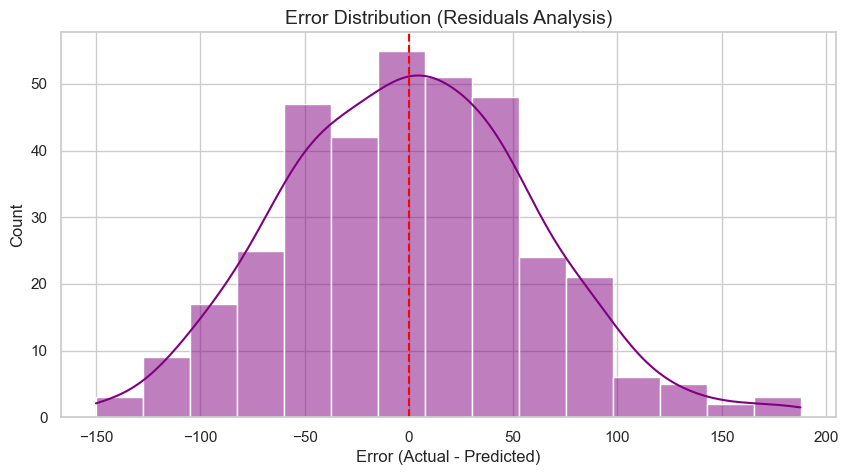

In [41]:
plt.figure(figsize=(10, 5))
residuals = y_actual - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Error Distribution (Residuals Analysis)', fontsize=14)
plt.xlabel('Error (Actual - Predicted)', fontsize=12)
plt.show()